In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import factorial

In [2]:
def debye_waller(q, m, B, omegas, ell, N):
    result=0
    for col in range(N):
        result+= B[ell][col]**2/omegas[col]
    result*=q**2/(4*m)
    return result

# Ignore

In [3]:
eigenvalues, eigenvectors = np.linalg.eig(np.diag((1, 2, 3)))

In [4]:
def getSpringConstants_matrix(gamma, N):
    k=np.pi**2/3
    for n in range(N):
        k-=2/(n+1)**2
    K = np.identity(N)*k
    for row in range(N):
        for col in range(N):
            if col!=row:
                K[row][col] = 1/(row-col)**2
    return K*gamma

In [5]:
def getKMatrix(gamma, N):
    k=np.pi**2/3
    for n in range(N):
        k-=2/(n+1)**2
    K = np.zeros((N,N))
    for row in range(N):
        diag=k
        for col in range(N):
            if col!=row:
                K[row][col] = 1/(row-col)**2
                diag+=K[row][col]
        K[row][row] = -diag
    return -K*gamma    

In [6]:
K = getKMatrix(1,5)
print(K)

[[ 1.78625702 -1.         -0.25       -0.11111111 -0.0625    ]
 [-1.          2.72375702 -1.         -0.25       -0.11111111]
 [-0.25       -1.          2.86264591 -1.         -0.25      ]
 [-0.11111111 -0.25       -1.          2.72375702 -1.        ]
 [-0.0625     -0.11111111 -0.25       -1.          1.78625702]]


In [7]:
'''K=getSpringConstants_matrix(1,2)
print(K)'''

'K=getSpringConstants_matrix(1,2)\nprint(K)'

In [8]:
eigenvalues, eigenvectors = np.linalg.eig(K)

In [9]:
print(eigenvalues)

[0.36264591 1.35933986 2.49880695 4.19870709 3.46317418]


In [10]:
print(eigenvectors)

[[-4.47213595e-01 -6.19422700e-01  5.25967134e-01 -1.52835121e-01
  -3.41050610e-01]
 [-4.47213595e-01 -3.41050610e-01 -2.36728183e-01  4.93922836e-01
   6.19422700e-01]
 [-4.47213595e-01  4.72773560e-16 -5.78477902e-01 -6.82175429e-01
  -3.52926310e-16]
 [-4.47213595e-01  3.41050610e-01 -2.36728183e-01  4.93922836e-01
  -6.19422700e-01]
 [-4.47213595e-01  6.19422700e-01  5.25967134e-01 -1.52835121e-01
   3.41050610e-01]]


# N-particle Structure Factor

In [11]:
def combos_helper_function_diag(j_vector, B, omegas, N, ell):
    # For each set of j, calculate the product in the structure factor in the diagonal term
    tot=1
    for r in range(N):
        if j_vector[r]!=0:
            tot*=1/factorial(j_vector[r])*(B[ell][r]**2/omegas[r])**j_vector[r]
    return tot

In [12]:
def combos_helper_function_offdiag(j_vector, B, omegas, N, ell, ell_prime):
    tot=1
    for r in range(N):
        if j_vector[r]!=0:
            tot*=1/factorial(j_vector[r])*(B[ell][r]*B[ell_prime][r]/omegas[r])**j_vector[r]
    return tot

In [13]:
def diagonal_C_singleCombo(q, m, omegas, n, j_vector,N,ell,B, V=1):
    # For each set of j, calculate one term in the summation of C_ll
    expDebyeWaller = np.exp(-2*debye_waller(q, m, B, omegas, ell, N))
    c=expDebyeWaller/V * (q**2/(2*m))**n * 2*np.pi* combos_helper_function_diag(j_vector, B, omegas, N, ell)
    return c

In [14]:
def offDiagonal_C_singleCombo(q, m, omegas, n, j_vector, N ,ell, ell_prime, B , V=1, a=0.001):
    expDebyeWaller = np.exp(-debye_waller(q, m, B, omegas, ell, N)-debye_waller(q, m, B, omegas, ell_prime, N))
    c=expDebyeWaller/V * (q**2/(2*m))**n * 2*np.pi*combos_helper_function_offdiag(j_vector, B, omegas, N, ell, ell_prime)
    c = c*np.cos(q*a*(ell-ell_prime))
    return c

In [15]:
def allj_One_n(n, N, end=[]):
    # given n, N, find all possible sets of j
    combos=[]
    if N==1:
        for row in end:
            combos.append([n-sum(row)]+row)
        return combos
    if len(end)==0:
        for value in range(n+1):
            combos.append([value])
        return allj_One_n(n, N-1, combos)
    for row in end:
        for j in range(n-sum(row)+1):
            combos.append([j]+row)
    return allj_One_n(n, N-1, combos)       

In [16]:
def StructureFactorIntegral_singleCombo(q, m, omegas, n, j, N ,B , V=1, a=0.001, A=1):
    # For each set of j, sum all C_ll terms over N
    tot=0
    for ell in range(N):
        for ell_prime in range(N):
            if ell==ell_prime:
                tot+=diagonal_C_singleCombo(q, m, omegas, n, j,N,ell,B, V)
            else:
                tot+=offDiagonal_C_singleCombo(q, m, omegas, n, j, N ,ell, ell_prime, B , V, a)
    return A**2 * tot

In [17]:
def StructureFactorIntegral_allj(q, m, omegas, n, N ,B , V=1, a=0.001, A=1):
    # sum over all sets of j
    j_combos = allj_One_n(n, N)
    tot=0
    for j in j_combos:
        tot+= StructureFactorIntegral_singleCombo(q, m, omegas, n, j, N ,B , V, a, A)
    return tot

In [18]:
m=26161e3
k=400e-6*m*1e-6
gamma=(3600e-6*m*1e-6-k)/2
N=2

K_param= np.zeros((N,N))
for row in range(N):
    for col in range(N):
        if row==col:
            if row==0 or row==N-1:
                K_param[row][col]= (k+gamma)/m
            else:
                K_param[row][col]= (k+2*gamma)/m
        elif row-col==1 or row-col==-1:
            K_param[row][col]= -(gamma)/m

In [19]:
omegas, B= np.linalg.eig(K_param)
B=B.T
omegas = np.array([np.sqrt(omegas[i]) for i in range(N)])
print(B)

[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [20]:
SFI_params = {'m':m, 'B':B, 'ome':omegas, 'V':5*N, "A":10, "a":2*np.pi/2.28, 'N':N}

In [21]:
log_q_values = np.linspace(-1, np.log10(300), 3000) 
q_values = 10**log_q_values # keV

In [22]:
SFI_allj =[]

for n in range(1,3):
    SFI_allj.append(np.array(
        [StructureFactorIntegral_allj(q, SFI_params['m'], SFI_params['ome'], n, SFI_params['N'] 
                                      ,SFI_params['B'] , SFI_params['V'], SFI_params['a'], SFI_params['A'])
                                            for q in q_values]))

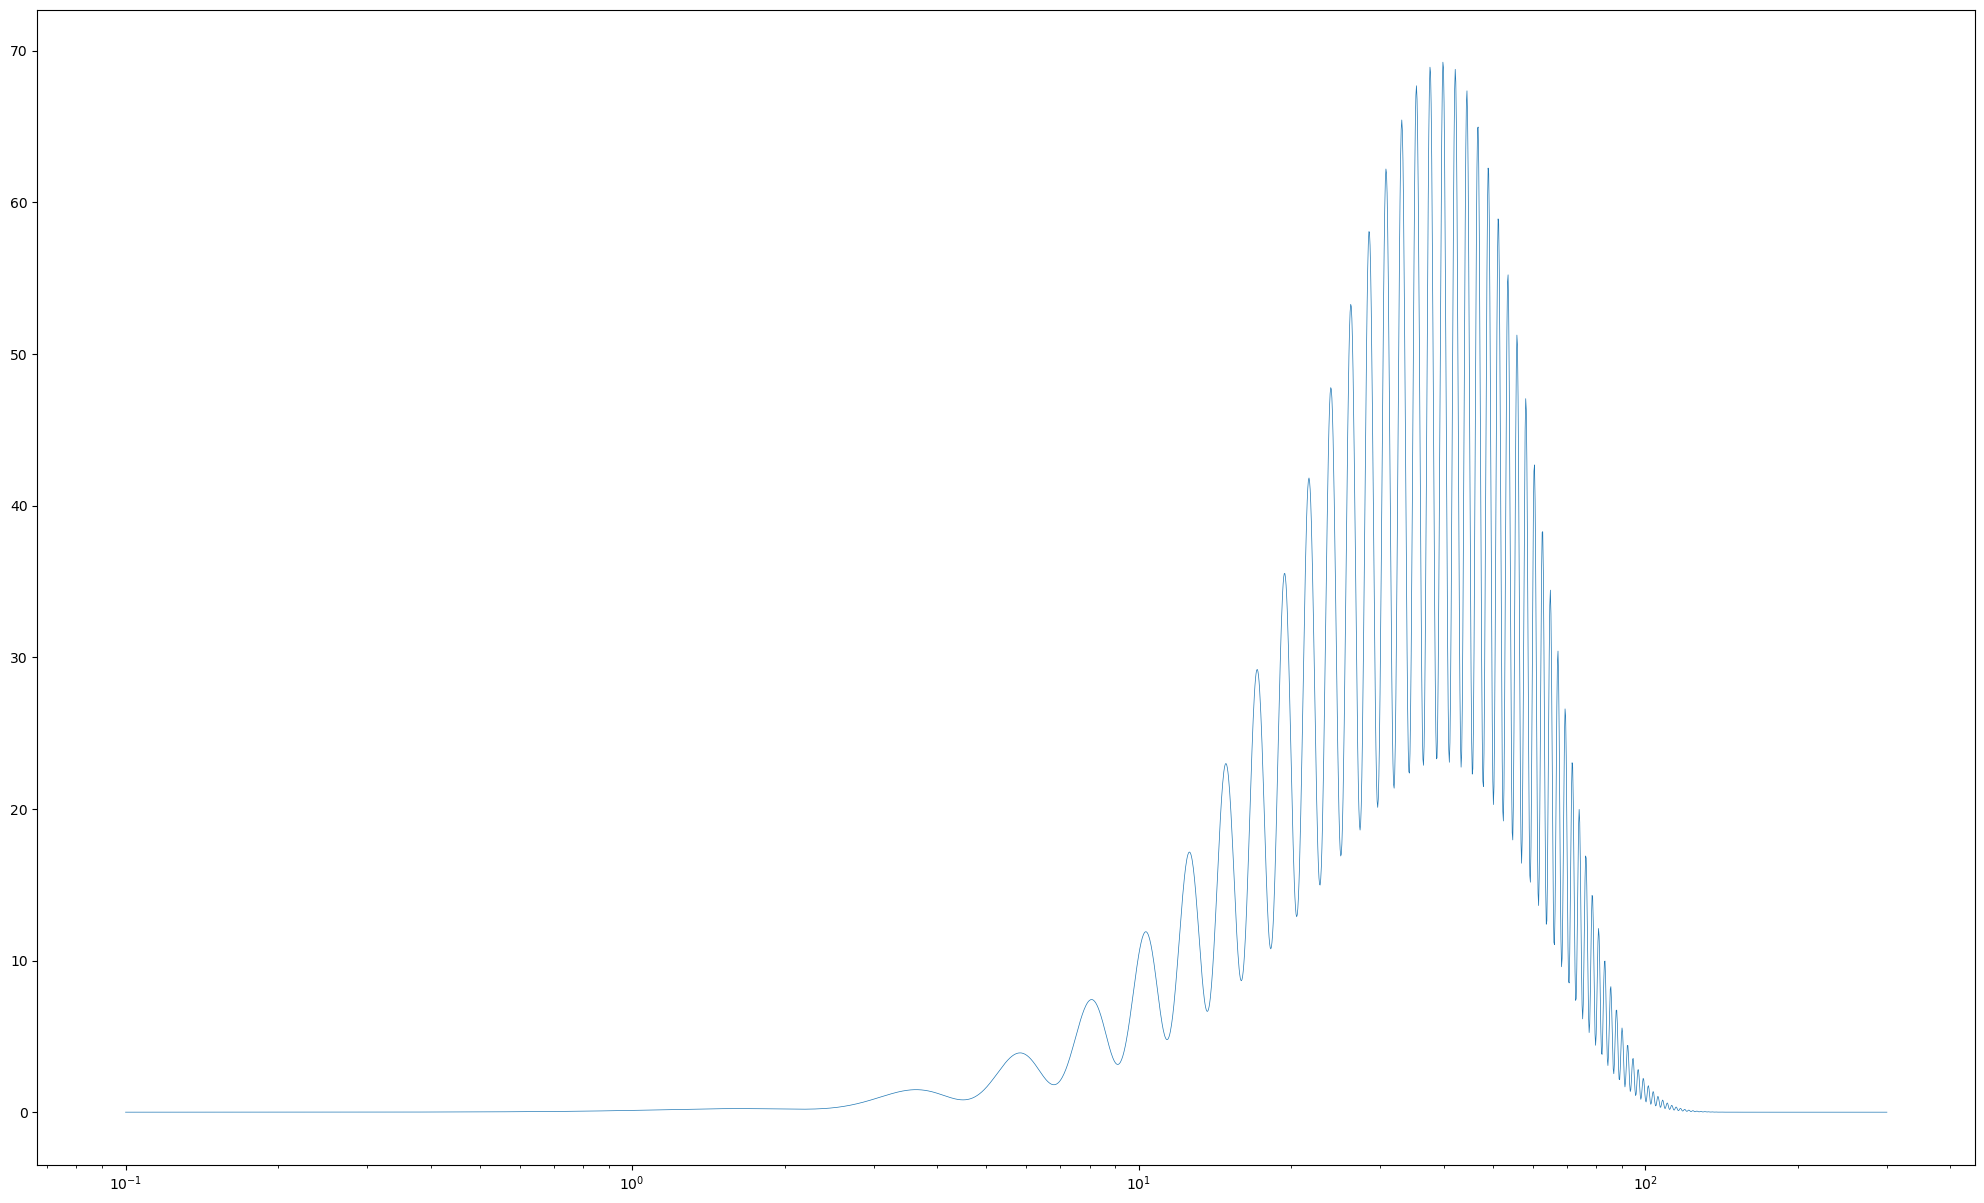

In [23]:
plt.figure(figsize=(25,15))
plt.plot(q_values,SFI_allj[0], linewidth=0.5)
plt.xscale('log')

# Using Calculated $\omega$ and eigenvectors

In [24]:
def getOmegas(k, gamma, m, N):
    ome = []
    for num in range(1, N+1):
        eigenvalue = -(k+2*gamma)/m+2*gamma/m*np.cos(num*np.pi/(N+1))
        if eigenvalue>0:
            print("error with omegas")
            print(eigenvalue)
            break
        ome.append(np.sqrt(-eigenvalue))
    return np.array(ome)

In [25]:
def getOmegas_Nok(gamma, m, N):
    ome = []
    for num in range(1, N+1):
        eigenvalue = 2*gamma/m*(1-np.cos(num*np.pi/(N+1)))
        ome.append(np.sqrt(eigenvalue))
    return ome

In [48]:
def getEigenvectors(N):
    A=np.sqrt(2/(N+1))
    B=np.zeros((N,N))
    for ell in range(N):
        for r in range(N):
            B[ell][r] = A*np.sin((r+1)*(ell+1)*np.pi/(N+1))
    return B

In [49]:
def StructureFactorIntegral_onlyCrossTerms(q, m, omegas, n, N ,B , V=1, a=0.001, A=1):
    j_combos = allj_One_n(n, N)
    tot=0
    for j in j_combos:
        for diag in range(N):
            tot+=diagonal_C_singleCombo(q, m, omegas, n, j,N,diag,B, V)*A**2
    return tot

In [50]:
log_q_values = np.linspace(0, np.log10(300), 3000) 
q_values = 10**log_q_values # keV

In [51]:
m=26161e3
k_0=400e-6*m*1e-6 #2-particle k-value
#gamma=(3600e-6*m*1e-6-k_0)/2
gamma = (30*10**-6)*m*(30*10**-6)
N=5

SFI_params = {'m':m, 'B':getEigenvectors(N), 'ome':getOmegas_Nok(gamma, m, N), 'V':5*N, "A":10, "a":2*np.pi/2.28, 'N':N}

In [52]:
SFI_allj =[]
SFI_allj_onlycross =[]

for n in range(1,3):
    SFI_allj.append(np.array(
        [StructureFactorIntegral_allj(q, SFI_params['m'], SFI_params['ome'], n, SFI_params['N'] 
                                      ,SFI_params['B'] , SFI_params['V'], SFI_params['a'], SFI_params['A'])
                                            for q in q_values]))
    SFI_allj_onlycross.append(np.array(
        [StructureFactorIntegral_onlyCrossTerms(q, SFI_params['m'], SFI_params['ome'], n, SFI_params['N'] 
                                      ,SFI_params['B'] , SFI_params['V'], SFI_params['a'], SFI_params['A'])
                                            for q in q_values]))    
    

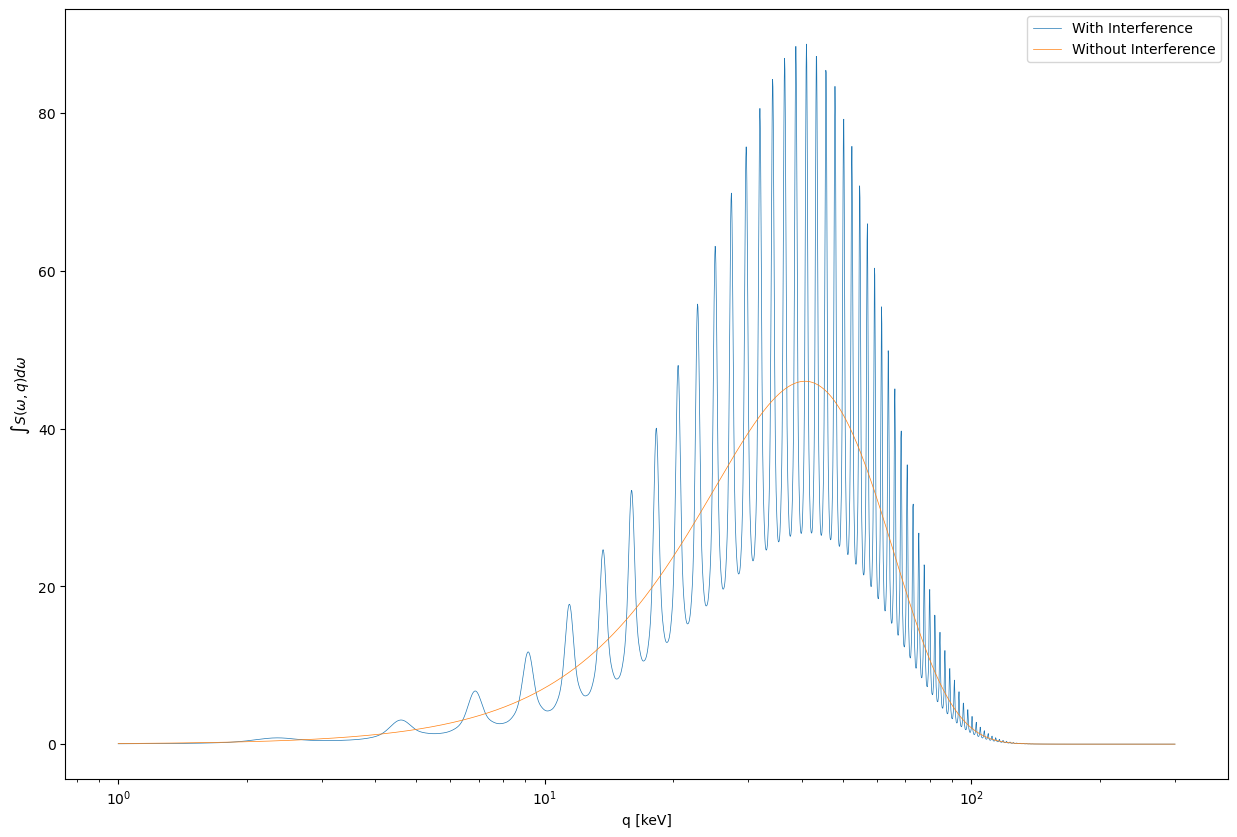

In [53]:
plt.figure(figsize=(15,10))
plt.plot(q_values,SFI_allj[0], label="With Interference", linewidth=0.5)
plt.plot(q_values, SFI_allj_onlycross[0], label="Without Interference", linewidth=0.5)
plt.legend()
plt.xlabel("q [keV]")
plt.ylabel("$\int S(\omega, q) d\omega$")
plt.xscale('log')

In [54]:
N_arr=[2,3,5,10]

SFI_params = {'m':m, "A":10, "a":2*np.pi/2.28, 'N':N_arr}
SFI_params['B'] = [getEigenvectors(N) for N in N_arr]
SFI_params['ome'] = [getOmegas_Nok(gamma, m, N) for N in N_arr]
SFI_params['V'] = [5*N for N in N_arr]

In [55]:
SFI_allj =[]


for i in range(len(N_arr)): #row is number of particles
    current=[]
    for n in range(1,3):  #column is phonon number
        current.append(np.array(
            [StructureFactorIntegral_allj(q, SFI_params['m'], SFI_params['ome'][i], n, SFI_params['N'][i] 
                                      ,SFI_params['B'][i] , SFI_params['V'][i], SFI_params['a'], SFI_params['A'])
                                            for q in q_values]))
    print(i)
    SFI_allj.append(current)

0
1
2
3


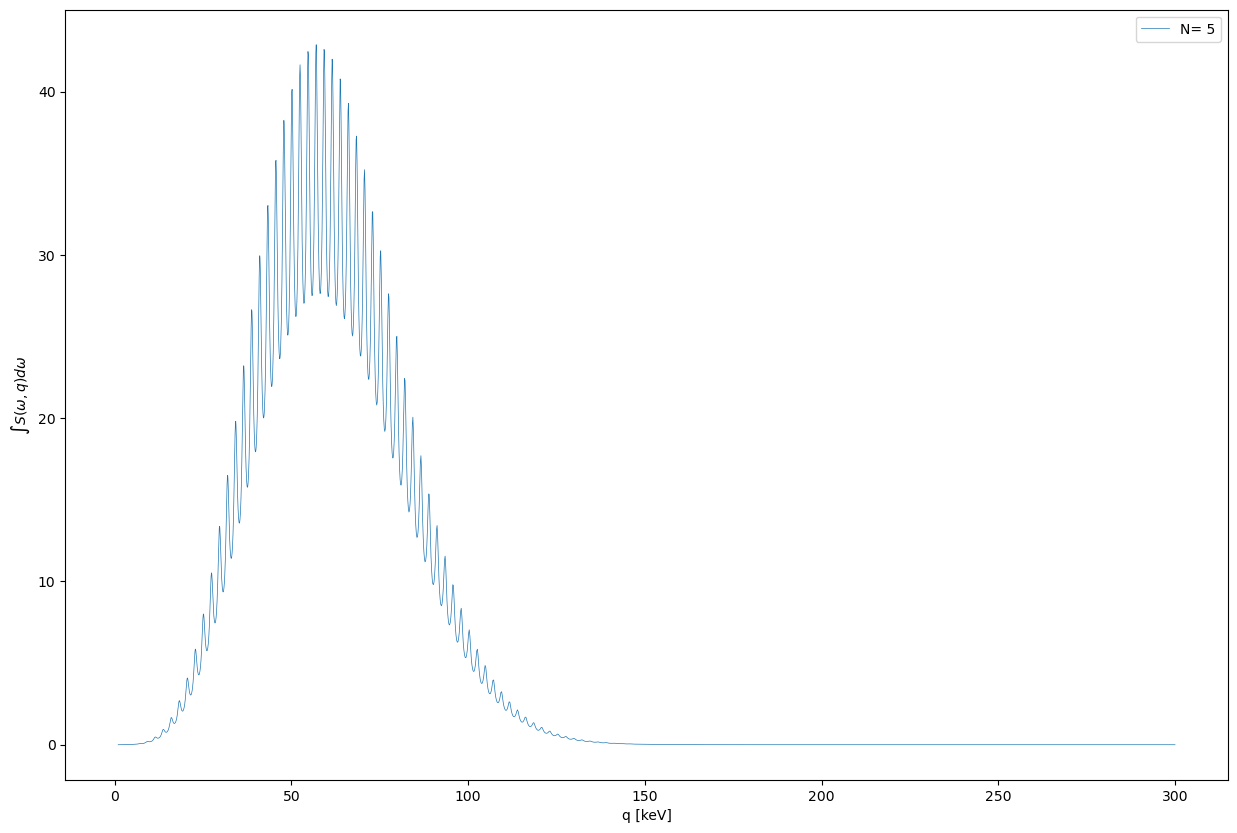

In [66]:
phonon_num = 0
plt.figure(figsize=(15,10))
#plt.plot(q_values,SFI_allj[0][phonon_num-1], linewidth=0.5, label="N= {value}".format(value=N_arr[0]))
#plt.plot(q_values,SFI_allj[1][phonon_num-1], linewidth=0.5, label="N= {value}".format(value=N_arr[1]))
plt.plot(q_values,SFI_allj[2][phonon_num-1], linewidth=0.5, label="N= {value}".format(value=N_arr[2]))
#plt.plot(q_values,SFI_allj[3][phonon_num-1], linewidth=0.5, label="N= {value}".format(value=N_arr[3]))
plt.xlabel("q [keV]")
plt.ylabel("$\int S(\omega, q) d\omega$")
#plt.xscale('log')
plt.legend()